In [ ]:
import heapq
import sys

import matplotlib
import matplotlib.pyplot as plt

IS_FILE_INPUT = True
ONLINE_JUDGE = True if len(sys.argv) >= 2 and sys.argv[1] == "ONLINE_JUDGE" else False


class Env:
    def __init__(self, input_file_path: str):
        with open(input_file_path) as f:
            lines = f.readlines()
            N, M, Q, L, W = map(int, lines[0].split())
            G = list(map(int, lines[1].split()))
            rectangles = []
            for l in range(2, 2 + N):
                rectangles.append(list(map(int, lines[l].split())))
            coordinates = []
            for l in range(2 + N, 2 + N + N):
                coordinates.append(list(map(int, lines[l].split())))

        self.N, self.M, self.Q, self.L, self.W = N, M, Q, L, W
        self.G = G
        self.rectangles = rectangles
        self.coordinates = coordinates
        self.cneter_points = [[(l + r) / 2, (c + d) / 2] for l, r, c, d in rectangles]
        self._query_history: list[str] = []

    def query(self, c_list: list[int]) -> list[tuple[int, int]]:
        query_str = " ".join(["?", str(len(c_list)), *map(str, c_list)])
        self._query_history.append(query_str)

        now_graph: dict[int, list] = {v: [] for v in c_list}
        for c1 in c_list:
            for c2 in c_list:
                if c1 == c2:
                    continue
                x1, y1 = self.coordinates[c1]
                x2, y2 = self.coordinates[c2]
                dist = abs(x1 - x2) ** 2 + abs(y1 - y2) ** 2
                now_graph[c1].append((c2, dist))
                now_graph[c2].append((c1, dist))

        ans_edges, ans_v = prim(now_graph)
        return ans_edges

    def answer(
        self,
        groups: list[list[int]],
        edges: list[list[tuple[int, int]]],
        output_file_path: str,
    ):
        ans_str = "!\n"
        for i in range(len(groups)):
            ans_str += " ".join(map(str, groups[i])) + "\n"
            for e in edges[i]:
                ans_str += " ".join(map(str, e)) + "\n"

        with open(output_file_path, "w") as f:
            for query_str in self._query_history:
                f.write(query_str + "\n")
            f.write(ans_str)

    def _input(self):
        W, D, N = map(int, input().split())
        a = []
        for d in range(D):
            a.append(list(map(int, input().split())))
        return W, D, N, a


def solve(env: Env):
    N, M, Q, L, W = env.N, env.M, env.Q, env.L, env.W
    G = env.G
    rectangles = env.rectangles
    lx, rx, ly, ry = [], [], [], []
    for n in range(N):
        a, b, c, d = rectangles[n]
        lx.append(a)
        rx.append(b)
        ly.append(c)
        ry.append(d)

    # use center of rectangle
    x = [(l + r) // 2 for l, r in zip(lx, rx)]
    y = [(l + r) // 2 for l, r in zip(ly, ry)]

    # split cities into groups
    cities = list(range(N))
    cities.sort(key=lambda i: (x[i], y[i]))
    groups = []
    start_idx = 0
    for g in G:
        groups.append(cities[start_idx : start_idx + g])
        start_idx += g

    # get edges from queries
    edges = []
    for k in range(M):
        edges.append([])
        for i in range(0, G[k] - 1, 2):
            if i < G[k] - 2:
                ret = env.query(groups[k][i : i + 3])
                edges[k].extend(ret)
            else:
                edges[k].append(groups[k][i : i + 2])

    env.answer(groups, edges, "../out/0000.txt")


env = Env("../in/0000.txt")


In [ ]:
from typing import List, Tuple

import numpy as np
from scipy.spatial import KDTree


def calc_dist(p1: tuple, p2: tuple) -> float:
    x_dff = p1[0] - p2[0]
    y_dff = p1[1] - p2[1]
    dist = (x_dff**2 + y_dff**2) ** 0.5
    return dist


def fast_greedy_pairing(points: List[Tuple[float, float]]) -> List[Tuple[int, int]]:
    points = np.array(points)
    n = len(points)
    used = np.zeros(n, dtype=bool)
    tree = KDTree(points)
    pairs = []

    for i in range(n):
        if used[i]:
            continue
        dists, indices = tree.query(points[i], k=min(30, n))
        for j in indices[1:]:
            if not used[j]:
                pairs.append((i, int(j)))
                used[i] = used[j] = True
                break

    return pairs


def farthest_point_sampling(points: np.ndarray, M: int) -> np.ndarray:
    N = len(points)
    selected_indices = []

    idx = np.random.randint(0, N)
    selected_indices.append(idx)
    min_distances = np.full(N, np.inf)

    for _ in range(1, M):
        last_point = points[selected_indices[-1]]
        distances = np.linalg.norm(points - last_point, axis=1)
        min_distances = np.minimum(min_distances, distances)
        next_idx = np.argmax(min_distances)
        selected_indices.append(int(next_idx))

    return selected_indices


def select_pairs(cneter_points, rectangles):
    N_POINT = 100
    N_PAIR = 20

    diffs = []
    for v, (l, r, t, b) in enumerate(rectangles):
        diffs.append((v, abs(l - r) + abs(t - b)))

    sorted_diffs = sorted(diffs, key=lambda x: x[1])

    target_diffs = sorted_diffs[:N_POINT]
    target_inds = [diff[0] for diff in target_diffs]
    target_points = [cneter_points[diff[0]] for diff in target_diffs]
    pairs = fast_greedy_pairing(target_points)
    pairs = [(target_inds[i], target_inds[j]) for i, j in pairs]
    pair_centers = []
    for v, q in pairs:
        pair_centers.append(
            [
                (cneter_points[v][0] + cneter_points[q][0]) / 2,
                (cneter_points[v][1] + cneter_points[q][1]) / 2,
            ]
        )
    sample_inds = farthest_point_sampling(np.array(pair_centers), N_PAIR)
    selected_pairs = []
    for i in sample_inds:
        selected_pairs.append(pairs[i])
    return selected_pairs

- ゆらぎの少ない 2 点で、かつ、2 点の間が小さいものを基準にする
- その 2 点の垂直二等分線でポリゴンが切れて、2 点がなすひし形とかぶらないポリゴンを見つけてくる
- そのポリゴンの中で最も面積の大きいポリゴンを選択
  - できれば平等に分割できるポリゴンがうれしい
    - 適当に 10%以上で分割できることとする？
- 3 点クエリを行い、本当の点がどこに存在するかを求める
- 上記を 400 回繰り返す

800 _ 400
3.2 _ 10^5


In [ ]:
import random

import matplotlib.pyplot as plt
from matplotlib.collections import PatchCollection
from matplotlib.patches import Polygon as MplPolygon
from shapely.geometry import LineString, Point, Polygon
from shapely.ops import split


def _extend_line_fixed_bounds(cut_point1, cut_point2, bounds_min=-1000, bounds_max=11000):
    # ベクトルの方向を正規化
    p1 = np.array(cut_point1)
    p2 = np.array(cut_point2)
    direction = p2 - p1
    direction = direction / np.linalg.norm(direction)

    # 直線の延長距離を大きくとる
    length = (bounds_max - bounds_min) * 2
    new_p1 = p1 - direction * length
    new_p2 = p2 + direction * length

    return LineString([new_p1, new_p2])


def split_polygon_with_extended_line(polygon, cut_point1, cut_point2):
    cutting_line = _extend_line_fixed_bounds(cut_point1, cut_point2)
    result = split(polygon, cutting_line)
    polygons = [geom for geom in result.geoms if isinstance(geom, Polygon)]
    return polygons


def perpendicular_bisector(point1, point2):
    """
    垂直二等分線
    """
    p1 = np.array(point1)
    p2 = np.array(point2)

    midpoint = (p1 + p2) / 2
    vec = p2 - p1
    norm = np.linalg.norm(vec)
    perp_vec = np.array([-vec[1], vec[0]]) / norm
    start = midpoint - perp_vec
    end = midpoint + perp_vec

    return LineString([start, end])


def create_my_custom_rect(point1, point2):
    """
    point1とpoint2を結ぶ線分と直角に交わる線分を利用して正方形を作る
    """
    p1 = np.array(point1)
    p2 = np.array(point2)

    midpoint = (p1 + p2) / 2
    vec = p2 - p1
    norm = np.linalg.norm(vec)
    perp_vec = np.array([-vec[1], vec[0]]) / norm**2
    square_points = [
        tuple(p1 - perp_vec),
        tuple(p1 + perp_vec),
        tuple(p2 + perp_vec),
        tuple(p2 - perp_vec),
    ]

    return Polygon(square_points)


CUT_RATIO = 0.1


class MyPolygon:
    def __init__(self, rect_points, ind):
        l, r, t, b = rect_points
        points = [
            (l, t),
            (r, t),
            (r, b),
            (l, b),
        ]
        self.polygon = Polygon(points)
        self.ind = ind

    def is_cutting(self, cut_point1, cut_point2):
        result_polygons = split_polygon_with_extended_line(self.polygon, cut_point1, cut_point2)
        custom_rect = create_my_custom_rect(cut_point1, cut_point2)
        if len(result_polygons) == 2 and self.polygon.interiors(custom_rect).is_empty():
            if min(result_polygons[0].area, result_polygons[1].area) > self.polygon.area * CUT_RATIO:
                return True
        return False

    def cut(self, cut_point1, cut_point2, near_point: int):
        result_polygons = split_polygon_with_extended_line(self.polygon, cut_point1, cut_point2)
        if near_point == 0:
            c1 = result_polygons[0].centroid
            c2 = result_polygons[1].centroid
            # point1との距離が近い方を選ぶ
            if c1.distance(Point(cut_point1)) < c2.distance(Point(cut_point1)):
                self.polygon = result_polygons[0]
            else:
                self.polygon = result_polygons[1]

    # intersection = polygon1.intersection(polygon2)
    # print(intersection.is_empty)

In [ ]:
FILE_NUM = 100
file_num = 0

input_file_path = f"../in/{file_num:04d}.txt"
env = Env(input_file_path)

In [ ]:
selected_pairs = select_pairs(env.cneter_points, env.rectangles)

CUT_TARGET_POLYS = 500
diffs = []
for v, (l, r, t, b) in enumerate(env.rectangles):
    diffs.append((v, abs(l - r) + abs(t - b)))

sorted_diffs = sorted(diffs, key=lambda x: x[1], reverse=True)[:CUT_TARGET_POLYS]

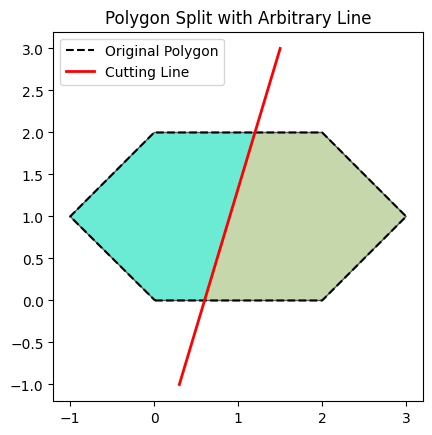

=== Polygon Areas ===
Polygon 1 Area: 2.795000000000182
Polygon 2 Area: 3.199999999999818

Point (-0.5, 0.6) is inside original polygon? True


In [ ]:
def plot_polygons(original_points, polygons, cutting_line):
    fig, ax = plt.subplots()
    ax.plot(*zip(*original_points, original_points[0]), "k--", label="Original Polygon")

    patches = []
    colors = []
    for poly in polygons:
        mpl_poly = MplPolygon(list(poly.exterior.coords), closed=True)
        patches.append(mpl_poly)
        colors.append((random.random(), random.random(), random.random()))

    p = PatchCollection(patches, facecolor=colors, edgecolor="k", alpha=0.6)
    ax.add_collection(p)

    x, y = cutting_line.xy
    ax.plot(x, y, "r-", linewidth=2, label="Cutting Line")

    ax.set_aspect("equal")
    ax.legend()
    plt.title("Polygon Split with Arbitrary Line")
    plt.show()


# 六角形のポリゴン
polygon_points = [(0.01, 0), (2, 0), (3, 1), (2, 2), (0, 2), (-1, 1)]

# 任意の2点で分割
cut_point1 = (0.3, -1)
cut_point2 = (1.5, 3)

# 分割
result_polygons, cutting_line = split_polygon_with_extended_line(polygon_points, cut_point1, cut_point2)

# 描画
plot_polygons(polygon_points, result_polygons, LineString([cut_point1, cut_point2]))

# 面積表示
print("=== Polygon Areas ===")
for v, poly in enumerate(result_polygons):
    print(f"Polygon {v + 1} Area: {poly.area}")

# 点の内包チェック
test_point = (-0.5, 0.6)
inside = is_point_inside_polygon(polygon_points, test_point)
print(f"\nPoint {test_point} is inside original polygon? {inside}")


False
array('d', [2.0, 3.0, 1.0, 0.0, 2.0]) array('d', [2.0, 1.0, 1.0, 2.0, 2.0])


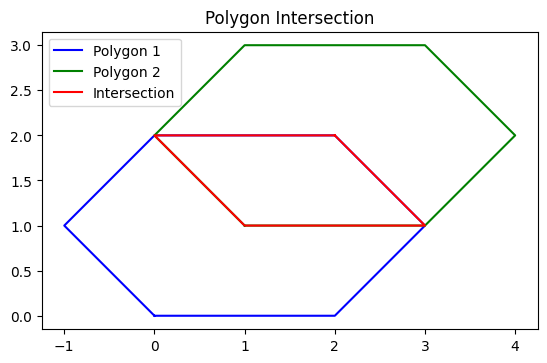

In [ ]:
from shapely.geometry import Polygon

# 2つのポリゴンを定義（10角形）、重ならないようにする
polygon1 = Polygon([(0, 0), (2, 0), (3, 1), (2, 2), (0, 2), (-1, 1)])
polygon2 = Polygon([(1, 1), (3, 1), (4, 2), (3, 3), (1, 3), (0, 2)])
# polygon2 = Polygon([(4, 4), (6, 4), (7, 5), (6, 6), (4, 6), (3, 5)])

# 共通部分（交差部分）を取得
intersection = polygon1.intersection(polygon2)
print(intersection.is_empty)


# polygon1、 polygon2、intersectionを描画
def plot_polygons_with_intersection(polygon1, polygon2, intersection):
    fig, ax = plt.subplots()
    x1, y1 = polygon1.exterior.xy
    x2, y2 = polygon2.exterior.xy
    x_int, y_int = intersection.exterior.xy
    print(x_int, y_int)

    ax.plot(x1, y1, color="blue", label="Polygon 1")
    ax.plot(x2, y2, color="green", label="Polygon 2")
    ax.plot(x_int, y_int, color="red", label="Intersection")

    ax.set_aspect("equal")
    ax.legend()
    plt.title("Polygon Intersection")
    plt.show()


plot_polygons_with_intersection(polygon1, polygon2, intersection)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define points A and B
A = np.array([0.0, 0.0])
B = np.array([1.0, 0.0])

# Angle of vector AB
vec_AB = B - A
theta = np.arctan2(vec_AB[1], vec_AB[0])  # radians

# Half angle for center line of the arc (30 degrees)
half_angle = np.deg2rad(30)
r = 1.0  # radius

# Directions from A (theta ± 30°)
A_dirs = [theta + half_angle, theta - half_angle]
A_arc_points = [A + r * np.array([np.cos(a), np.sin(a)]) for a in A_dirs]

# Directions from B (theta + pi ± 30°)
theta_BA = theta + np.pi
B_dirs = [theta_BA + half_angle, theta_BA - half_angle]
B_arc_points = [B + r * np.array([np.cos(a), np.sin(a)]) for a in B_dirs]


# Arc drawing function
def draw_arc(ax, center, base_angle, radius, arc_angle, color="gray"):
    angles = np.linspace(base_angle - arc_angle, base_angle + arc_angle, 100)
    arc_x = center[0] + radius * np.cos(angles)
    arc_y = center[1] + radius * np.sin(angles)
    ax.plot(arc_x, arc_y, color=color, linestyle="--", alpha=0.5)


# Plotting
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([A[0], B[0]], [A[1], B[1]], "k--", label="Axis A→B")

# Arcs
draw_arc(ax, A, theta, r, half_angle, color="blue")
draw_arc(ax, B, theta_BA, r, half_angle, color="green")

# Lines and intersection points from A
for pt, label in zip(A_arc_points, ["A+30°", "A−30°"]):
    ax.plot([A[0], pt[0]], [A[1], pt[1]], "b-", lw=1)
    ax.plot(pt[0], pt[1], "ro")
    ax.text(pt[0] + 0.05, pt[1] + 0.05, label, fontsize=9)

# Lines and intersection points from B
for pt, label in zip(B_arc_points, ["B+30°", "B−30°"]):
    ax.plot([B[0], pt[0]], [B[1], pt[1]], "g-", lw=1)
    ax.plot(pt[0], pt[1], "ro")
    ax.text(pt[0] + 0.05, pt[1] + 0.05, label, fontsize=9)

# Points A and B
ax.plot(*A, "ko")
ax.text(*A + 0.05, "A", fontsize=12)
ax.plot(*B, "ko")
ax.text(*B + 0.05, "B", fontsize=12)

ax.set_aspect("equal")
ax.grid(True)
ax.set_title("Arc directions ±30° from A→B and B→A")
plt.legend()
plt.tight_layout()
plt.show()
